# Unit 3 — companion notebook
Code for the worked examples in the [Unit 3 notes](https://elevien.github.io/math50_sandbox/unit3/).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, binom

rng = np.random.default_rng(0)

### Example: Binomial via the CLT

In [2]:
N, q = 200, 0.3
trials = 100000

exact = binom.cdf(N//2 - 1, N, q)

z = np.sqrt(N) * (1 - 2*q) / (2 * np.sqrt(q * (1 - q)))
clt_approx = norm.cdf(z)

samples = rng.binomial(N, q, size=trials)
mc_estimate = np.mean(samples < N/2)

print(f"Exact:       {exact:.4f}")
print(f"CLT approx:  {clt_approx:.4f}")
print(f"Monte Carlo: {mc_estimate:.4f}")

Exact:       1.0000
CLT approx:  1.0000
Monte Carlo: 1.0000


### Example: sample distribution of a Normal mean

In [3]:
mu, sigma, N = 5, 2, 30
reps = 100_000
mu_hats = rng.normal(mu, sigma, size=(reps, N)).mean(axis=1)

print("mean(mu_hat) ~", mu_hats.mean(), " (theory:", mu, ")")
print("se(mu_hat)   ~", mu_hats.std(), " (theory sigma/sqrt(N):", sigma/np.sqrt(N), ")")

mean(mu_hat) ~ 4.999111374438999  (theory: 5 )
se(mu_hat)   ~ 0.36475537347930576  (theory sigma/sqrt(N): 0.3651483716701107 )


### Example: bias and consistency

In [4]:
mu, sigma = 3, 5
reps = 200_000
Y = rng.normal(mu, sigma, size=(reps, 2))
mu2_hat = Y.mean(axis=1)  # (Y1+Y2)/2

print("E[mu2_hat] ~", mu2_hat.mean(), " (theory:", mu, ")")
print("se(mu2_hat) ~", mu2_hat.std(), " (theory sigma/sqrt(2):", sigma/np.sqrt(2), ")")

E[mu2_hat] ~ 2.9962805164868342  (theory: 3 )
se(mu2_hat) ~ 3.5369895102515674  (theory sigma/sqrt(2): 3.5355339059327373 )


### Example: Bessel's correction

In [5]:
mu, sigma, n = 0, 3, 5
reps = 200_000
Y = rng.normal(mu, sigma, size=(reps, n))

sigma0_sq = Y.var(axis=1, ddof=0)  # divide by n
sigma_sq = Y.var(axis=1, ddof=1)   # divide by n-1

print("E[sigma0^2] (biased)   ~", sigma0_sq.mean(), " (true sigma^2:", sigma**2, ")")
print("E[sigma^2]  (unbiased) ~", sigma_sq.mean())

E[sigma0^2] (biased)   ~ 7.208948979103947  (true sigma^2: 9 )
E[sigma^2]  (unbiased) ~ 9.011186223879934


### Example: sample size for a target CI width

In [6]:
sigma, mu = 1, 0
for n in [3, 4, 8]:
    reps = 20_000
    Y = rng.normal(mu, sigma, size=(reps, n))
    mu_hat = Y.mean(axis=1)
    se = sigma / np.sqrt(n)
    lo, hi = mu_hat - 1.96 * se, mu_hat + 1.96 * se
    coverage = np.mean((lo < mu) & (mu < hi))
    print(f"n={n}: CI width={hi[0]-lo[0]:.3f}, coverage={coverage:.3f}")

n=3: CI width=2.263, coverage=0.949
n=4: CI width=1.960, coverage=0.952
n=8: CI width=1.386, coverage=0.950


### Example: marketing data

beta0 = 7.032593549127703  beta1 = 0.047536640433019695


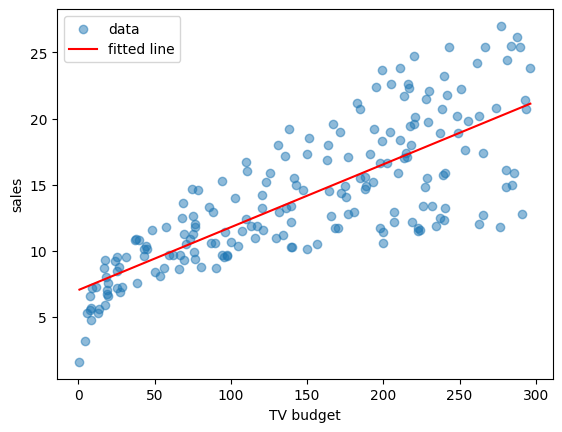

In [7]:
df = pd.read_csv("https://www.statlearning.com/s/Advertising.csv")
x, y = df["TV"].values, df["sales"].values

beta1 = np.cov(x, y)[0, 1] / np.cov(x, y)[0, 0]
beta0 = y.mean() - beta1 * x.mean()
print("beta0 =", beta0, " beta1 =", beta1)

xs = np.linspace(x.min(), x.max(), 100)
plt.scatter(x, y, alpha=0.5, label="data")
plt.plot(xs, beta0 + beta1 * xs, color="red", label="fitted line")
plt.xlabel("TV budget")
plt.ylabel("sales")
plt.legend()
plt.show()

### Example: marketing data — simulating fake datasets

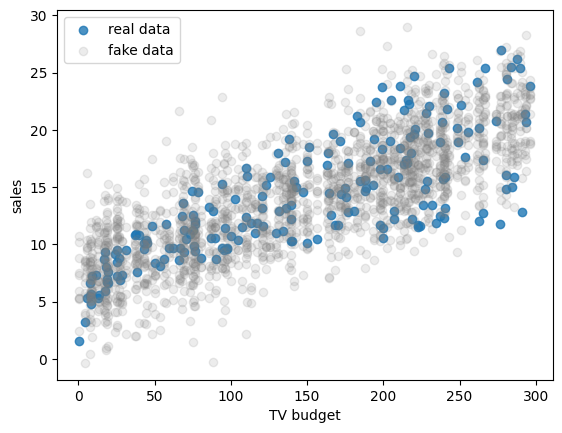

In [8]:
n = len(x)
sigma_hat = np.std(y - (beta0 + beta1 * x), ddof=2)

plt.scatter(x, y, alpha=0.8, color="tab:blue", label="real data")
for i in range(10):
    y_fake = beta0 + beta1 * x + rng.normal(0, sigma_hat, size=n)
    plt.scatter(x, y_fake, alpha=0.15, color="gray", label="fake data" if i == 0 else None)
plt.xlabel("TV budget")
plt.ylabel("sales")
plt.legend()
plt.show()

### Example: simulating the Hurwicz bias

In [9]:
rho = 0.6

def fit_rho_hat(T):
    eps = rng.normal(size=T)
    Y = np.empty(T)
    Y[0] = eps[0]
    for t in range(1, T):
        Y[t] = rho * Y[t - 1] + eps[t]
    y_lag, y = Y[:-1], Y[1:]
    return np.sum(y_lag * y) / np.sum(y_lag**2)

for T in [10, 50, 200]:
    rho_hats = [fit_rho_hat(T) for _ in range(20_000)]
    print(f"T={T}: average rho_hat = {np.mean(rho_hats):.3f}")

T=10: average rho_hat = 0.504
T=50: average rho_hat = 0.578


T=200: average rho_hat = 0.595


### Example: hypothesis testing for a binary-predictor regression model

In [10]:
mu_C, mu_T, sigma, N = 10, 10.5, 2, 200

XC = rng.normal(mu_C, sigma, size=N // 2)
XT = rng.normal(mu_T, sigma, size=N // 2)

beta1_hat = XT.mean() - XC.mean()
se_beta1 = np.sqrt(4 * sigma**2 / N)
T_stat = beta1_hat / se_beta1
p_value = 2 * (1 - norm.cdf(abs(T_stat)))

print("beta1_hat =", beta1_hat)
print("T =", T_stat)
print("p-value =", p_value)

beta1_hat = 0.2868023180254706
T = 1.0139993196791555
p-value = 0.31058307692006504
